In [1]:
from transformers import GPT2Tokenizer, GPT2LMHeadModel
from transformers import ClapProcessor, ClapModel
import librosa
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import numpy as np

In [ ]:
from datasets import load_from_disk

ds = load_from_disk("../musiccaps/dataset_audio")
len(ds)

# preliminary results
# framework direkt metric output edicek
# machine translation metrics, BLEU, ROUGE, METEOR, CIDEr, bertscore

Loading dataset from disk:   0%|          | 0/19 [00:00<?, ?it/s]

5305

In [3]:
# First split: separate test set (held out for final evaluation only)
ds_split = ds.train_test_split(test_size=0.1, seed=42)
ds_train_val = ds_split["train"]
ds_test = ds_split["test"]

# Second split: split train+val into train and validation sets
ds_train_val_split = ds_train_val.train_test_split(test_size=0.1, seed=42)
ds_train = ds_train_val_split["train"]
ds_val = ds_train_val_split["test"]

print(f"Train: {len(ds_train)}, Val: {len(ds_val)}, Test: {len(ds_test)}")

Train: 4296, Val: 478, Test: 531


In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device


'cuda'

In [5]:

# CLAP (frozen)
clap_processor = ClapProcessor.from_pretrained("laion/clap-htsat-unfused")
clap = ClapModel.from_pretrained("laion/clap-htsat-unfused").to(device)
clap.eval()
for p in clap.parameters():
    p.requires_grad = False

# GPT-2
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

gpt2 = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
gpt2.eval()
for p in gpt2.parameters():
    p.requires_grad = False
    
# T5
# musicgen

/home/aliozkaya/miniconda3/envs/musicgen/lib/python3.10/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [6]:
D_AUDIO = clap.config.projection_dim      # e.g. 512
D_LM = gpt2.config.n_embd                 # 768
PREFIX_LEN = 16  # Increased from 8 for better conditioning

In [7]:
projection = nn.Sequential(
    nn.Linear(D_AUDIO, D_LM * 2),      # 512 → 1536
    nn.LayerNorm(D_LM * 2),            # Add layer normalization
    nn.GELU(),
    nn.Dropout(0.35),                    # Increased dropout
    nn.Linear(D_LM * 2, D_LM * 4),     # 1536 → 3072
    nn.LayerNorm(D_LM * 4),            # Add layer normalization
    nn.GELU(),
    nn.Dropout(0.35),                    # Increased dropout
    nn.Linear(D_LM * 4, PREFIX_LEN * D_LM),  # 3072 → PREFIX_LEN * 768
).to(device)
projection.train()

# Text projection for contrastive loss (audio space)
text_projection = nn.Sequential(
    nn.Linear(D_LM, D_AUDIO),
    nn.LayerNorm(D_AUDIO),
    nn.Dropout(0.5),
    nn.GELU(),
).to(device)
text_projection.train()

Sequential(
  (0): Linear(in_features=768, out_features=512, bias=True)
  (1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): GELU(approximate='none')
)

In [8]:
optimizer = torch.optim.AdamW(
    list(projection.parameters()) + list(text_projection.parameters()),
    lr=5e-4,
    weight_decay=0.1
)

# Loss weights
CONTRASTIVE_WEIGHT = 0.03  # Weight for contrastive loss
MATCHING_WEIGHT = 0.05    # Weight for audio-text matching loss


In [ ]:
def get_audio_embedding(sample):
    """Get audio embedding for a single sample"""
    audio = sample["audio"]["array"]
    sr = sample["audio"]["sampling_rate"]

    if audio.ndim == 2:
        audio = audio.mean(axis=1)

    if sr != 48000:
        audio = librosa.resample(audio, orig_sr=sr, target_sr=48000)

    inputs = clap_processor(
        audio=audio,
        sampling_rate=48000,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        emb = clap.get_audio_features(**inputs)

    return emb  # (1, D_AUDIO)

def get_audio_embeddings_batch(samples):
    """Get audio embeddings for a batch of samples"""
    audios = []
    for sample in samples:
        audio = sample["audio"]["array"]
        sr = sample["audio"]["sampling_rate"]
        
        if audio.ndim == 2:
            audio = audio.mean(axis=1)
        
        if sr != 48000:
            audio = librosa.resample(audio, orig_sr=sr, target_sr=48000)
        
        audios.append(audio)
    
    inputs = clap_processor(
        audio=audios,
        sampling_rate=48000,
        return_tensors="pt"
    ).to(device)
    
    with torch.no_grad():
        embs = clap.get_audio_features(**inputs)
    
    return embs  # (batch_size, D_AUDIO)

def get_text_embedding_clap(text):
    """Get text embedding from CLAP for alignment"""
    text_inputs = clap_processor(
        text=[text],
        return_tensors="pt",
        padding=True
    ).to(device)
    
    with torch.no_grad():
        text_emb = clap.get_text_features(**text_inputs)
    return text_emb  # (1, D_AUDIO)

def contrastive_loss(audio_emb, text_emb, temperature=0.07):
    """
    Contrastive loss to align audio and text embeddings.
    For single samples, this becomes a simple cosine similarity loss.
    audio_emb: (batch_size, D_AUDIO)
    text_emb: (batch_size, D_AUDIO) - projected text embedding
    """
    # Normalize embeddings
    audio_emb = F.normalize(audio_emb, dim=1)
    text_emb = F.normalize(text_emb, dim=1)
    
    # For single sample, use cosine similarity loss (maximize similarity)
    if audio_emb.size(0) == 1:
        # Simple cosine similarity: maximize dot product of normalized vectors
        similarity = (audio_emb * text_emb).sum(dim=1)
        # Loss: minimize negative similarity (maximize similarity)
        return -similarity.mean()
    else:
        # For batch > 1, use full contrastive loss
        # Compute similarity matrix
        logits = torch.matmul(audio_emb, text_emb.T) / temperature
        
        # Labels: diagonal should be high (matching pairs)
        labels = torch.arange(audio_emb.size(0), device=audio_emb.device)
        
        loss = F.cross_entropy(logits, labels)
        return loss

def audio_text_matching_loss(audio_emb, captions):
    """
    Use CLAP to compute audio-text similarity loss.
    Maximize similarity between audio and its caption.
    captions: single string or list of strings
    """
    if isinstance(captions, str):
        captions = [captions]
    
    text_inputs = clap_processor(
        text=captions,
        return_tensors="pt",
        padding=True
    ).to(device)
    
    with torch.no_grad():
        text_emb = clap.get_text_features(**text_inputs)
    
    # Normalize embeddings
    audio_emb_norm = F.normalize(audio_emb, dim=1)
    text_emb_norm = F.normalize(text_emb, dim=1)
    
    # Compute cosine similarity (should be high for matching pairs)
    similarity = (audio_emb_norm * text_emb_norm).sum(dim=1)
    
    # Loss: minimize negative similarity (maximize similarity)
    return -similarity.mean()

def compute_alignment_score(audio_emb, caption):
    """
    Compute CLAP similarity score for monitoring.
    Returns a score between -1 and 1 (higher is better).
    """
    text_emb = get_text_embedding_clap(caption)
    
    audio_emb_norm = F.normalize(audio_emb, dim=1)
    text_emb_norm = F.normalize(text_emb, dim=1)
    similarity = (audio_emb_norm * text_emb_norm).sum(dim=1).item()
    return similarity


In [10]:
def train_step_batch(samples, return_components=False):
    """
    Training step with batch processing:
    1. Language modeling loss (original)
    2. Contrastive loss (audio-text alignment)
    3. Audio-text matching loss (CLAP-based)
    
    samples: list of dataset samples
    """
    batch_size = len(samples)
    
    # Get audio embeddings for batch
    audio_embs = get_audio_embeddings_batch(samples)  # (batch_size, D_AUDIO)
    
    # Projection → prefix tokens
    prefix = projection(audio_embs)  # (batch_size, PREFIX_LEN * D_LM)
    prefix = prefix.view(batch_size, PREFIX_LEN, D_LM)
    
    # Tokenize captions
    captions = [s["caption"] for s in samples]
    tokens = tokenizer(
        captions,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=128
    ).to(device)
    
    input_ids = tokens.input_ids  # (batch_size, T)
    attention_mask = tokens.attention_mask
    
    # Text embeddings
    text_embeds = gpt2.transformer.wte(input_ids)  # (batch_size, T, D_LM)
    
    # Concatenate prefix + text
    inputs_embeds = torch.cat([prefix, text_embeds], dim=1)  # (batch_size, PREFIX_LEN + T, D_LM)
    
    # Labels (ignore prefix and padding)
    labels = input_ids.clone()
    ignore_prefix = torch.full((batch_size, PREFIX_LEN), -100, device=device)
    labels = torch.cat([ignore_prefix, labels], dim=1)
    
    # Set padding tokens to -100 in labels
    ignore_padding = torch.full((batch_size, PREFIX_LEN), -100, device=device)
    padding_mask = torch.cat([ignore_padding, 1 - attention_mask], dim=1)
    labels = labels.masked_fill(padding_mask.bool(), -100)
    
    # Language modeling loss
    outputs = gpt2(
        inputs_embeds=inputs_embeds,
        labels=labels
    )
    lm_loss = outputs.loss
    
    # Contrastive loss: align audio embedding with text embedding
    # Get mean text embedding (excluding padding) and project to audio space
    # Mask out padding tokens
    text_lengths = attention_mask.sum(dim=1, keepdim=True)  # (batch_size, 1)
    text_mean_emb = (text_embeds * attention_mask.unsqueeze(-1)).sum(dim=1) / text_lengths  # (batch_size, D_LM)
    text_proj_emb = text_projection(text_mean_emb)  # (batch_size, D_AUDIO)
    contrastive = contrastive_loss(audio_embs, text_proj_emb)
    
    # Audio-text matching loss using CLAP
    matching = audio_text_matching_loss(audio_embs, captions)
    
    # Combined loss
    total_loss = lm_loss + CONTRASTIVE_WEIGHT * contrastive + MATCHING_WEIGHT * matching
    
    if return_components:
        return total_loss, {
            "lm_loss": lm_loss.item(),
            "contrastive_loss": contrastive.item(),
            "matching_loss": matching.item()
        }
    return total_loss

def train_step(sample, return_components=False):
    """
    Single sample training step (for backward compatibility)
    """
    return train_step_batch([sample], return_components)


In [11]:
from pathlib import Path

SAVE_DIR = Path("checkpoints")
SAVE_DIR.mkdir(exist_ok=True)

# Batch size for training
BATCH_SIZE = 64 # Adjust based on GPU memory
VAL_BATCH_SIZE = 64  # Can be larger for validation (no gradients)

# Create DataLoaders
def collate_fn(batch):
    """Custom collate function for audio samples"""
    return batch  # Return list as-is, we'll process in train_step_batch

train_loader = DataLoader(
    ds_train,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=0  # Set to 0 to avoid multiprocessing issues with audio
)

val_loader = DataLoader(
    ds_val,
    batch_size=VAL_BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=0
)

In [12]:
from tqdm import tqdm

best_val_loss = float("inf")

EPOCHS = 30

all_train_losses = []
all_val_losses = []
epoch_train_losses = []
epoch_val_losses = []
epoch_train_alignments = []
epoch_val_alignments = []

for epoch in tqdm(range(EPOCHS), desc="Training"):
    # ============ TRAINING ============
    projection.train()  # set to train mode
    text_projection.train()
    total_train_loss = 0.0
    total_train_lm = 0.0
    total_train_contrastive = 0.0
    total_train_matching = 0.0
    total_train_alignment = 0.0
    valid_batches = 0
    valid_samples = 0

    for batch in tqdm(train_loader, desc="Train", leave=False):
        try:
            optimizer.zero_grad()
            loss, components = train_step_batch(batch, return_components=True)
            loss.backward()
            
            # Gradient clipping to prevent instability
            torch.nn.utils.clip_grad_norm_(
                list(projection.parameters()) + list(text_projection.parameters()),
                max_norm=1.0
            )
            
            optimizer.step()
            
            batch_size = len(batch)
            all_train_losses.append(loss.item())
            total_train_loss += loss.item() * batch_size
            total_train_lm += components["lm_loss"] * batch_size
            total_train_contrastive += components["contrastive_loss"] * batch_size
            total_train_matching += components["matching_loss"] * batch_size
            valid_batches += 1
            valid_samples += batch_size
            
            # Compute alignment score every 10 batches
            if valid_batches % 10 == 0:
                with torch.no_grad():
                    sample = batch[0]
                    audio_emb = get_audio_embedding(sample)
                    alignment = compute_alignment_score(audio_emb, sample["caption"])
                    total_train_alignment += alignment
        except RuntimeError as e:
            if "No audio frames were decoded" in str(e) or "out of memory" in str(e).lower():
                if "out of memory" in str(e).lower():
                    torch.cuda.empty_cache()
                continue
            raise e

    avg_train_loss = total_train_loss / valid_samples
    avg_train_lm = total_train_lm / valid_samples
    avg_train_contrastive = total_train_contrastive / valid_samples
    avg_train_matching = total_train_matching / valid_samples
    avg_train_alignment = total_train_alignment / max(1, valid_batches // 10)
    epoch_train_losses.append(avg_train_loss)
    epoch_train_alignments.append(avg_train_alignment)

    # ============ VALIDATION ============
    projection.eval()  # set to eval mode
    text_projection.eval()
    total_val_loss = 0.0
    total_val_lm = 0.0
    total_val_contrastive = 0.0
    total_val_matching = 0.0
    total_val_alignment = 0.0
    val_batches = 0
    val_samples = 0

    with torch.no_grad():  # no gradients needed for validation
        for batch in tqdm(val_loader, desc="Val", leave=False):
            try:
                loss, components = train_step_batch(batch, return_components=True)
                batch_size = len(batch)
                all_val_losses.append(loss.item())
                total_val_loss += loss.item() * batch_size
                total_val_lm += components["lm_loss"] * batch_size
                total_val_contrastive += components["contrastive_loss"] * batch_size
                total_val_matching += components["matching_loss"] * batch_size
                val_batches += 1
                val_samples += batch_size
                
                # Compute alignment score every 5 batches
                if val_batches % 5 == 0:
                    sample = batch[0]
                    audio_emb = get_audio_embedding(sample)
                    alignment = compute_alignment_score(audio_emb, sample["caption"])
                    total_val_alignment += alignment
            except RuntimeError as e:
                if "No audio frames were decoded" in str(e) or "out of memory" in str(e).lower():
                    if "out of memory" in str(e).lower():
                        torch.cuda.empty_cache()
                    continue

    avg_val_loss = total_val_loss / val_samples
    avg_val_lm = total_val_lm / val_samples
    avg_val_contrastive = total_val_contrastive / val_samples
    avg_val_matching = total_val_matching / val_samples
    avg_val_alignment = total_val_alignment / max(1, val_batches // 5)
    epoch_val_losses.append(avg_val_loss)
    epoch_val_alignments.append(avg_val_alignment)
    
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save({
            "projection_state_dict": projection.state_dict(),
            "text_projection_state_dict": text_projection.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "epoch": epoch + 1,
            "val_loss": best_val_loss,
        }, SAVE_DIR / "projection_best.pt")

    print(f"Epoch {epoch+1}:")
    print(f"  Train - Loss: {avg_train_loss:.4f} (LM: {avg_train_lm:.4f}, "
          f"Contrastive: {avg_train_contrastive:.4f}, Matching: {avg_train_matching:.4f}), "
          f"Alignment: {avg_train_alignment:.4f}")
    print(f"  Val   - Loss: {avg_val_loss:.4f} (LM: {avg_val_lm:.4f}, "
          f"Contrastive: {avg_val_contrastive:.4f}, Matching: {avg_val_matching:.4f}), "
          f"Alignment: {avg_val_alignment:.4f}")

Training:   3%|▎         | 1/30 [01:45<50:53, 105.30s/it]

Epoch 1:
  Train - Loss: 3.4430 (LM: 3.3560, Contrastive: 3.8483, Matching: -0.5700), Alignment: 0.5528
  Val   - Loss: 3.0622 (LM: 3.0010, Contrastive: 2.9969, Matching: -0.5733), Alignment: 0.6652


Training:   7%|▋         | 2/30 [03:29<48:54, 104.79s/it]

Epoch 2:
  Train - Loss: 2.9763 (LM: 2.9108, Contrastive: 3.1359, Matching: -0.5701), Alignment: 0.6156
  Val   - Loss: 2.8776 (LM: 2.8300, Contrastive: 2.5418, Matching: -0.5733), Alignment: 0.6652


Training:  10%|█         | 3/30 [05:15<47:25, 105.40s/it]

...

Epoch 14:
  Train - Loss: 2.2497 (LM: 2.2256, Contrastive: 1.7542, Matching: -0.5701), Alignment: 0.5926
  Val   - Loss: 2.6703 (LM: 2.6478, Contrastive: 1.7065, Matching: -0.5733), Alignment: 0.6652


Training:  50%|█████     | 15/30 [26:27<27:03, 108.25s/it]

Epoch 15:
  Train - Loss: 2.2056 (LM: 2.1819, Contrastive: 1.7391, Matching: -0.5700), Alignment: 0.5803
  Val   - Loss: 2.7126 (LM: 2.6904, Contrastive: 1.6937, Matching: -0.5733), Alignment: 0.6652


Training:  50%|█████     | 15/30 [28:05<28:05, 112.35s/it]


KeyboardInterrupt: 

In [13]:
# Load the best model checkpoint
checkpoint = torch.load(SAVE_DIR / "projection_best.pt")
projection.load_state_dict(checkpoint["projection_state_dict"])
text_projection.load_state_dict(checkpoint["text_projection_state_dict"])

# Set to evaluation mode
projection.eval()
text_projection.eval()
gpt2.eval()

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D()
          (c_proj): Conv1D()
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D()
          (c_proj): Conv1D()
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [16]:
sample = ds_test[1]  # or any sample
audio_emb = get_audio_embedding(sample)
prefix = projection(audio_emb)
prefix = prefix.view(1, PREFIX_LEN, D_LM)

In [ ]:
# Create attention mask for prefix (all ones since we attend to all prefix tokens)
attention_mask = torch.ones(1, PREFIX_LEN, dtype=torch.long, device=device)

# Option 1: Lower temperature sampling (more deterministic, less hallucination)
generated_sample = gpt2.generate(
    inputs_embeds=prefix,
    attention_mask=attention_mask,
    max_length=100,
    do_sample=True,
    temperature=0.3,         # Lower temperature (was 0.8) - reduces randomness
    top_k=20,                # Lower top_k (was 50) - more focused
    top_p=0.8,               # Lower top_p (was 0.9) - more focused
    repetition_penalty=1.3,  # Higher repetition penalty (was 1.2)
    no_repeat_ngram_size=3,
)
print("Sampling (temp=0.3):")
print(tokenizer.decode(generated_sample[0], skip_special_tokens=True))
print()

# Option 2: Beam search (most deterministic, best for evaluation)
generated_beam = gpt2.generate(
    inputs_embeds=prefix,
    attention_mask=attention_mask,
    max_length=80,
    num_beams=5,             # Use beam search
    early_stopping=True,
    repetition_penalty=1.3,
    no_repeat_ngram_size=3,
)
print("Beam search (beams=5):")
print(tokenizer.decode(generated_beam[0], skip_special_tokens=True))
print()

# Show ground truth for comparison
print("Ground truth:")
print(sample["caption"])


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Sampling (temp=0.3):
The low quality recording features a blues song and it consists of an electric guitar solo melody played over shimmering hi hats. The stereo image is noisy, muted and lacks any detail in the soundstage or background noise. It sounds passionate but not overly emotional - like something you would hear at home on TV shows where people are talking about their favorite songs with friends who have been playing them for hours without being able to finish what

Beam search (beams=5):
The low quality recording features a live performance of a blues song and it consists of an electric guitar solo melody played over shimmering hi hats. The recording is noisy and moody. It sounds passionate and passionate. It could be playing in the background. This song can be played at a bar or in a bar. It

Ground truth:
The music is a country song instrumental. The tempo is slow with an auto harp harmony and lively acoustic guitar accompaniment. The music is soft, mellow, mellifluous,dulce

In [19]:
from IPython.display import Audio
Audio(sample["audio"]["array"], rate=sample["audio"]["sampling_rate"])

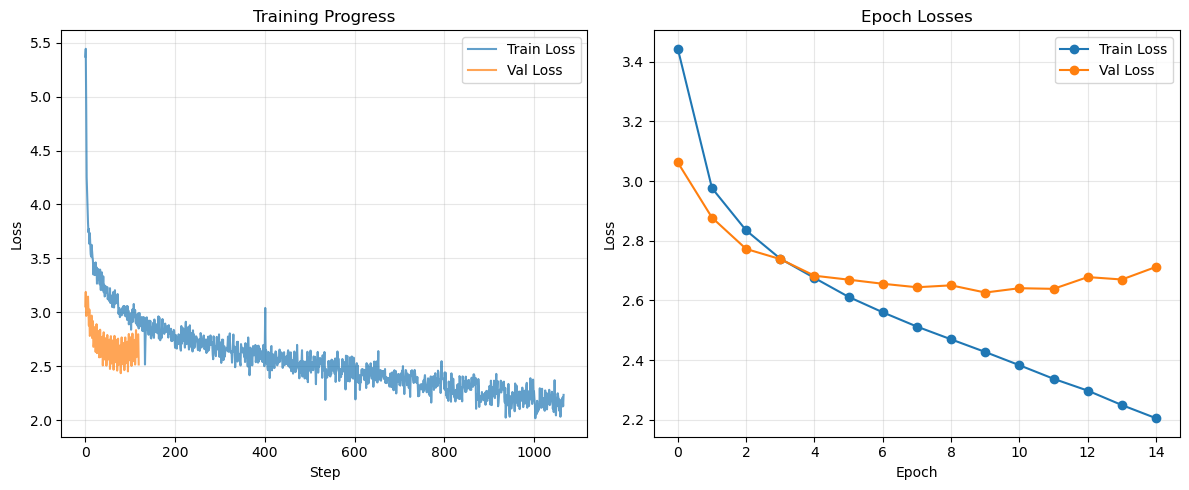

In [21]:
import matplotlib.pyplot as plt

# Plot training losses
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(all_train_losses, label='Train Loss', alpha=0.7)
plt.plot(all_val_losses, label='Val Loss', alpha=0.7)
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Training Progress')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epoch_train_losses, label='Train Loss', marker='o')
plt.plot(epoch_val_losses, label='Val Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Epoch Losses')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

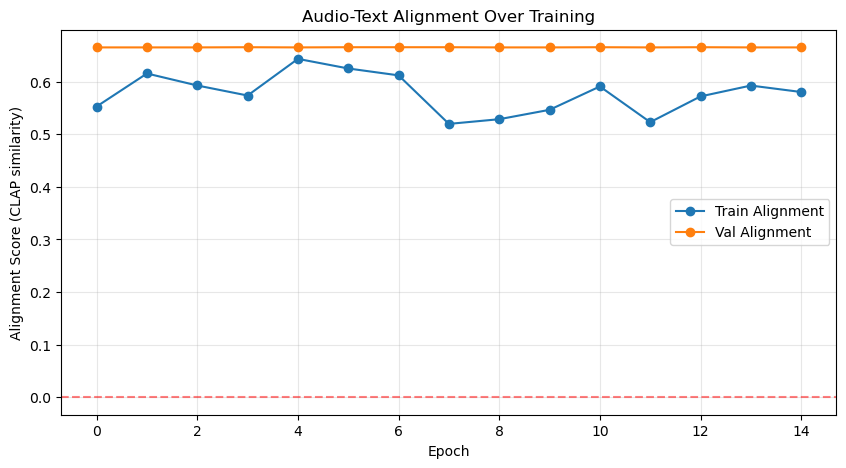

In [22]:
# Plot alignment scores over epochs
plt.figure(figsize=(10, 5))
plt.plot(epoch_train_alignments, label='Train Alignment', marker='o')
plt.plot(epoch_val_alignments, label='Val Alignment', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Alignment Score (CLAP similarity)')
plt.title('Audio-Text Alignment Over Training')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5, label='Zero alignment')
plt.show()

In [23]:
# ============ STAGE 2: Unfreeze GPT-2 ============

# Unfreeze GPT-2
for p in gpt2.parameters():
    p.requires_grad = True
gpt2.train()
projection.train()
text_projection.train()

# New optimizer with different LRs
optimizer = torch.optim.AdamW([
    {"params": projection.parameters(), "lr": 1e-4},
    {"params": text_projection.parameters(), "lr": 1e-4},
    {"params": gpt2.parameters(), "lr": 5e-6},
], weight_decay=0.1)

EPOCHS_STAGE2 = 10
best_val_loss = float('inf')

for epoch in tqdm(range(EPOCHS_STAGE2), desc="Stage 2"):
    # ---- Training ----
    projection.train()
    text_projection.train()
    gpt2.train()
    total_train_loss = 0.0
    total_train_lm = 0.0
    total_train_contrastive = 0.0
    total_train_matching = 0.0
    train_batches = 0
    train_samples = 0

    for batch in tqdm(train_loader, desc="Train", leave=False):
        try:
            optimizer.zero_grad()
            loss, components = train_step_batch(batch, return_components=True)
            loss.backward()          # gradients for projection, text_projection AND gpt2
            
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(
                list(projection.parameters()) + 
                list(text_projection.parameters()) + 
                list(gpt2.parameters()),
                max_norm=1.0
            )
            
            optimizer.step()         # updates projection at 1e-4, gpt2 at 5e-6
            
            batch_size = len(batch)
            total_train_loss += loss.item() * batch_size
            total_train_lm += components["lm_loss"] * batch_size
            total_train_contrastive += components["contrastive_loss"] * batch_size
            total_train_matching += components["matching_loss"] * batch_size
            train_batches += 1
            train_samples += batch_size
        except RuntimeError as e:
            if "No audio frames were decoded" in str(e) or "out of memory" in str(e).lower():
                if "out of memory" in str(e).lower():
                    torch.cuda.empty_cache()
                continue

    avg_train_loss = total_train_loss / train_samples
    avg_train_lm = total_train_lm / train_samples
    avg_train_contrastive = total_train_contrastive / train_samples
    avg_train_matching = total_train_matching / train_samples

    # ---- Validation ----
    projection.eval()
    text_projection.eval()
    gpt2.eval()
    total_val_loss = 0.0
    total_val_lm = 0.0
    total_val_contrastive = 0.0
    total_val_matching = 0.0
    val_batches = 0
    val_samples = 0

    with torch.no_grad():
        for batch in tqdm(val_loader, desc="Val", leave=False):
            try:
                loss, components = train_step_batch(batch, return_components=True)
                batch_size = len(batch)
                total_val_loss += loss.item() * batch_size
                total_val_lm += components["lm_loss"] * batch_size
                total_val_contrastive += components["contrastive_loss"] * batch_size
                total_val_matching += components["matching_loss"] * batch_size
                val_batches += 1
                val_samples += batch_size
            except RuntimeError as e:
                if "No audio frames were decoded" in str(e) or "out of memory" in str(e).lower():
                    if "out of memory" in str(e).lower():
                        torch.cuda.empty_cache()
                    continue

    avg_val_loss = total_val_loss / val_samples
    avg_val_lm = total_val_lm / val_samples
    avg_val_contrastive = total_val_contrastive / val_samples
    avg_val_matching = total_val_matching / val_samples
    
    print(f"Epoch {epoch+1}:")
    print(f"  Train - Loss: {avg_train_loss:.4f} (LM: {avg_train_lm:.4f}, "
          f"Contrastive: {avg_train_contrastive:.4f}, Matching: {avg_train_matching:.4f})")
    print(f"  Val   - Loss: {avg_val_loss:.4f} (LM: {avg_val_lm:.4f}, "
          f"Contrastive: {avg_val_contrastive:.4f}, Matching: {avg_val_matching:.4f})")
    
    # Save best model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save({
            'projection': projection.state_dict(),
            'text_projection': text_projection.state_dict(),
            'gpt2': gpt2.state_dict(),
        }, SAVE_DIR / 'best_model_stage2.pt')
        print(f"  ↳ Saved best model!")

Stage 2:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1:
  Train - Loss: 3.1358 (LM: 3.1120, Contrastive: 1.7462, Matching: -0.5703)
  Val   - Loss: 2.7067 (LM: 2.6854, Contrastive: 1.6672, Matching: -0.5733)


Stage 2:  10%|█         | 1/10 [01:50<16:35, 110.57s/it]

  ↳ Saved best model!


Epoch 2:
  Train - Loss: 2.8030 (LM: 2.7802, Contrastive: 1.7115, Matching: -0.5702)
  Val   - Loss: 2.6282 (LM: 2.6073, Contrastive: 1.6518, Matching: -0.5734)


...

Stage 2:  90%|█████████ | 9/10 [16:55<01:50, 110.69s/it]

  ↳ Saved best model!


Epoch 10:
  Train - Loss: 2.2835 (LM: 2.2626, Contrastive: 1.6456, Matching: -0.5702)
  Val   - Loss: 2.3668 (LM: 2.3467, Contrastive: 1.6275, Matching: -0.5734)


Stage 2: 100%|██████████| 10/10 [19:03<00:00, 114.37s/it]

  ↳ Saved best model!


In [ ]:
# Load Stage 2 model (includes fine-tuned GPT-2)
checkpoint = torch.load(SAVE_DIR / "best_model_stage2.pt")
projection.load_state_dict(checkpoint["projection"])
text_projection.load_state_dict(checkpoint["text_projection"])
gpt2.load_state_dict(checkpoint["gpt2"])  # Load fine-tuned GPT-2
projection.eval()
text_projection.eval()
gpt2.eval()

# Test on a few samples
print("Testing on test set samples:\n")
for idx in range(min(5, len(ds_test))):
    sample = ds_test[idx]
    audio_emb = get_audio_embedding(sample)
    prefix = projection(audio_emb)
    prefix = prefix.view(1, PREFIX_LEN, D_LM)
    
    # Create attention mask for prefix (all ones since we attend to all prefix tokens)
    attention_mask = torch.ones(1, PREFIX_LEN, dtype=torch.long, device=device)
    
    # Generate with beam search
    generated = gpt2.generate(
        inputs_embeds=prefix,
        attention_mask=attention_mask,
        max_length=100,
        num_beams=10,
        early_stopping=True,
        repetition_penalty=1.3,
        no_repeat_ngram_size=3,
        length_penalty=1.0,
    )
    
    generated_text = tokenizer.decode(generated[0], skip_special_tokens=True)
    alignment_score = compute_alignment_score(audio_emb, sample["caption"])
    
    print(f"Sample {idx+1}:")
    print(f"  Ground truth: {sample['caption']}")
    print(f"  Generated: {generated_text}")
    print(f"  Alignment score: {alignment_score:.4f}")
    print()


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Testing on test set samples:



The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Sample 1:
  Ground truth: A female vocalist sings this soft love song in a foreign language. The tempo is medium with a mellifluous violin harmony, keyboard accompaniment, subtle bass, steady drumming and rhythmic acoustic guitar. The song is sweet, youthful, simple, romantic, sentimental, melancholic and pensive. This song is Romantic Pop.
  Generated: The low quality recording features a live performance of a pop song that consists of passionate female vocal singing over groovy piano melody, shimmering hi hats, mellow synth keys melody and punchy kick hits. It sounds emotional, passionate and passionate - like something you would hear in a movie or TV show. The recording is noisy and it sounds emotional. It could be used in the soundtrack of a romantic comedy movie. It
  Alignment score: 0.5728



The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Sample 2:
  Ground truth: The music is a country song instrumental. The tempo is slow with an auto harp harmony and lively acoustic guitar accompaniment. The music is soft, mellow, mellifluous,dulcet, sentimental, simple and nostalgic.
  Generated: The low quality recording features a mellow electric guitar melody played over shimmering hi hats, shimmering e-guitar chords, groovy bass guitar melody and shimmering electric guitar chords. It sounds passionate, passionate and emotional. The recording is noisy and in mono. It may be playing in the background at a coffee shop. It could also be playing at a live performance. This song can be played in a
  Alignment score: 0.4698



The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Sample 3:
  Ground truth: This is the live recording of a pop music piece. The track is being performed with playback. There is a female vocal with child-like characteristics. There is a strong electronic drum beat in the rhythmic background. A fuzzy synth bass is playing the melodic part. There are lots of beat repeat effects. The atmosphere is loud and energetic. There are sounds that can be heard coming from the crowd cheering.
  Generated: The low quality recording features a live performance of a pop song that consists of passionate female vocal singing over punchy kick and snare hits, shimmering hi hats and crowd cheering. It sounds energetic, energetic and energetic. The recording is noisy and it sounds like it was recorded with a phone. It could be used in the soundtrack of a crime drama movie. It may be playing at a live concert. This song may
  Alignment score: 0.5335



The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Sample 4:
  Ground truth: someone is playing a digital piano composition while a male voice is singing loudly a melody with long notes. In the background birds chirping and other noises can be heard. This is an amateur recording. This song may be playing in a live performance.
  Generated: The low quality recording features a passionate male vocal singing over mellow piano melody and arpeggiated acoustic guitar melody. It sounds emotional, mellow and mellow - like something you would hear in a romantic movie scene. The recording is noisy and it sounds emotional. It could be used in the soundtrack of a romantic drama movie. It would also fit perfectly in the background of a romance movie scene where you can hear
  Alignment score: 0.6598

Sample 5:
  Ground truth: This is a classical music piece played with the virtual sounds of a wind orchestra. The orchestra is composed of the oboe, the clarinet, the basset horn, the bassoon and the contrabass. The piece is in major key which gives th